# Chapter 5: Temporal Trajectories of Cognitive Collapse

## 5.1 Introduction
In the previous chapter, we established that the cognitive state (regime) is the primary predictor of operational failure, and that inherent traits—such as fatigue sensitivity—act as critical risk multipliers during a breakdown. 

However, cognitive collapse is not a static event; it is a dynamic, time-bound process. In this chapter, we introduce the temporal dimension to map the behavioral trajectories of operators over time. Our primary goal is to identify the precise moment where accumulated fatigue overwhelms the cognitive system, triggering the inevitable shift into the Burnout regime.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# load the dataset
df = pd.read_csv("../data/human_performance_dataset.csv")
print(df.shape)
print(df.dtypes)
display(df.head())

(975425, 19)
step                             int64
trajectory_id                    int64
regime                          object
reaction_time                  float64
error_rate                     float64
motivation                     float64
timestamp                       object
task_type                       object
task_difficulty                float64
time_pressure                   object
error_severity                  object
downstream_cost                  int64
risk_score                     float64
skill_baseline                 float64
fatigue_sensitivity            float64
resilience_factor              float64
mission_failure_probability    float64
expected_loss                  float64
intervention_effectiveness     float64
dtype: object


,step,trajectory_id,regime,reaction_time,error_rate,motivation,timestamp,task_type,task_difficulty,time_pressure,error_severity,downstream_cost,risk_score,skill_baseline,fatigue_sensitivity,resilience_factor,mission_failure_probability,expected_loss,intervention_effectiveness
0,0,0,NORMAL,409.990811,0.064074,8.271224,2023-07-25 14:58:53.016006783,monitoring,0.418229,low,minor,0,25.361594,0.676819,0.984083,0.765658,0.078432,0.000000,0.518212
1,1,0,NORMAL,604.333789,0.063963,6.984834,2023-07-25 15:09:08.920586166,monitoring,0.369670,low,minor,0,23.882631,0.676819,0.984083,0.765658,0.068387,0.000000,0.518212
2,2,0,NORMAL,549.450027,0.064438,6.230788,2023-07-25 15:19:56.821859704,monitoring,0.527565,low,minor,0,28.714490,0.676819,0.984083,0.765658,0.106353,0.000000,0.518212
3,3,0,NORMAL,479.728081,0.065361,5.936007,2023-07-25 15:29:20.158798225,reaction,0.718383,low,minor,50,34.623683,0.676819,0.984083,0.765658,0.176880,8.843991,0.518212
4,4,0,NORMAL,565.509924,0.064799,4.890426,2023-07-25 15:40:21.260736285,analysis,0.833457,low,minor,50,37.963558,0.676819,0.984083,0.765658,0.230828,11.541379,0.518212


In [2]:
df.columns.tolist()

['step',
 'trajectory_id',
 'regime',
 'reaction_time',
 'error_rate',
 'motivation',
 'timestamp',
 'task_type',
 'task_difficulty',
 'time_pressure',
 'error_severity',
 'downstream_cost',
 'risk_score',
 'skill_baseline',
 'fatigue_sensitivity',
 'resilience_factor',
 'mission_failure_probability',
 'expected_loss',
 'intervention_effectiveness']

## 5.2 Initial Time-Series Exploration

We begin by isolating the `timestamp` variable to understand the duration of the operational task. By calculating the average `risk_score` across all operators at each specific timestamp, we can visualize the global trajectory of performance degradation. This global trend will serve as the baseline for identifying the critical tipping point.

=== Timestamp Summary ===


count                            975425
unique                           975425
top       2023-07-25 14:58:53.016006783
freq                                  1
Name: timestamp, dtype: object

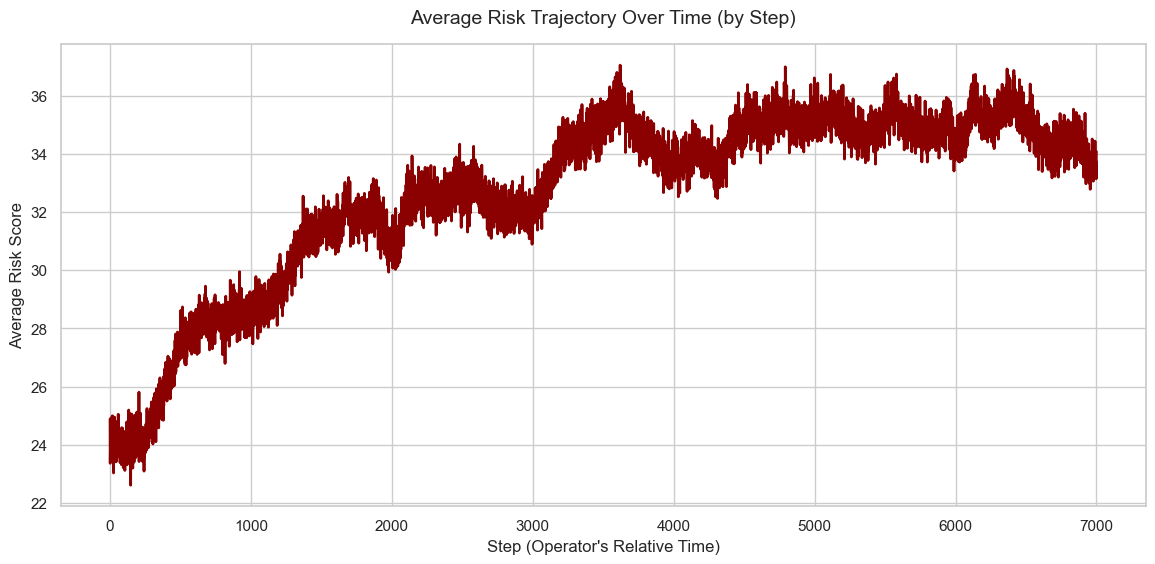

In [3]:
# Inspect the temporal boundaries
print("=== Timestamp Summary ===")
display(df['timestamp'].describe())

# 'step' is the shared relative time axis across operators,
# not 'timestamp' (which is unique per row and doesn't aggregate anything)

time_grouped = df.groupby('step')['risk_score'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=time_grouped, x='step', y='risk_score', color='darkred', linewidth=2)

plt.title("Average Risk Trajectory Over Time (by Step)", fontsize=14, pad=15)
plt.xlabel("Step (Operator's Relative Time)", fontsize=12)
plt.ylabel("Average Risk Score", fontsize=12)
plt.show()

In [4]:
# Per ogni operatore (trajectory_id), trovo il primo 'step' in cui il regime è BURNOUT
burnout_onset = (
    df[df['regime'] == 'BURNOUT']
    .groupby('trajectory_id')['step']
    .min()
    .reset_index()
    .rename(columns={'step': 'burnout_onset_step'})
)

print(f"Trajectories which reach burnout: {burnout_onset.shape[0]} on {df['trajectory_id'].nunique()}")
burnout_onset.head()

Trajectories which reach burnout: 20 on 140


,trajectory_id,burnout_onset_step
0,7,4605
1,11,3576
2,13,3078
3,28,5842
4,33,4374


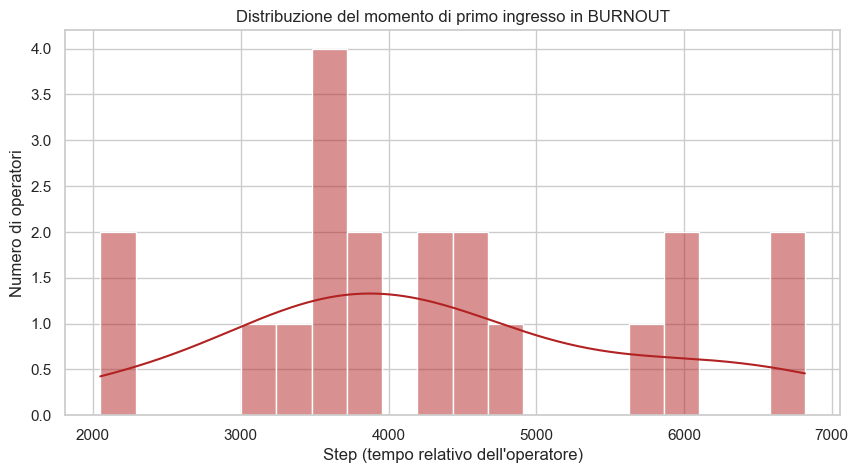

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(burnout_onset['burnout_onset_step'], bins=20, color='firebrick', kde=True)
plt.title("Distribuzione del momento di primo ingresso in BURNOUT")
plt.xlabel("Step (tempo relativo dell'operatore)")
plt.ylabel("Numero di operatori")
plt.show()

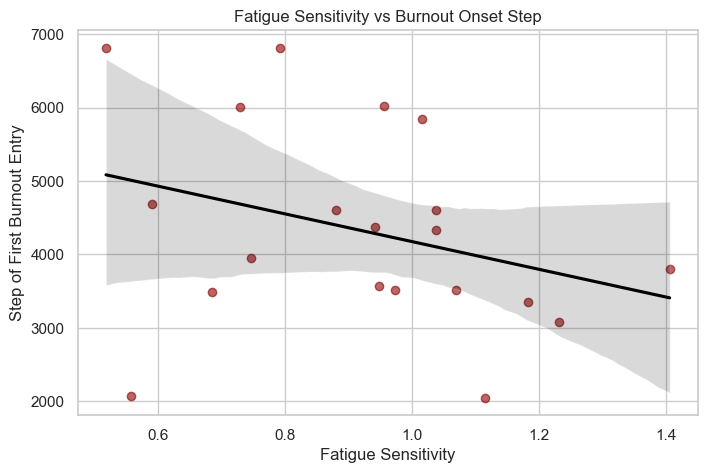

                     fatigue_sensitivity  burnout_onset_step
fatigue_sensitivity             1.000000           -0.319939
burnout_onset_step             -0.319939            1.000000


In [6]:
# fatigue_sensitivity is constant per operator, so keep one value per trajectory_id
traits = df[['trajectory_id', 'fatigue_sensitivity']].drop_duplicates()

# merge with the burnout onset table
burnout_analysis = burnout_onset.merge(traits, on='trajectory_id')

plt.figure(figsize=(8, 5))
sns.regplot(
    data=burnout_analysis,
    x='fatigue_sensitivity',
    y='burnout_onset_step',
    scatter_kws={'alpha': 0.6, 'color': 'darkred'},
    line_kws={'color': 'black'}
)
plt.title("Fatigue Sensitivity vs Burnout Onset Step")
plt.xlabel("Fatigue Sensitivity")
plt.ylabel("Step of First Burnout Entry")
plt.show()

# numerical correlation
print(burnout_analysis[['fatigue_sensitivity', 'burnout_onset_step']].corr())

In [7]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(burnout_analysis['fatigue_sensitivity'], burnout_analysis['burnout_onset_step'])
print(f"Correlation: {corr:.3f}, p-value: {p_value:.4f}")

Correlation: -0.320, p-value: 0.1691


In [8]:
# Get the list of trajectory_id that ever reached BURNOUT (from burnout_onset, already computed)
burnout_ids = burnout_onset['trajectory_id'].unique()

# Build a table with one row per operator, flagging whether they ever collapsed
group_comparison = df[['trajectory_id', 'fatigue_sensitivity']].drop_duplicates()
group_comparison['reached_burnout'] = group_comparison['trajectory_id'].isin(burnout_ids)

print(group_comparison['reached_burnout'].value_counts())

reached_burnout
False    120
True      20
Name: count, dtype: int64


/tmp/ipykernel_43285/3753999151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=group_comparison, x='reached_burnout', y='fatigue_sensitivity', palette=['steelblue', 'firebrick'])


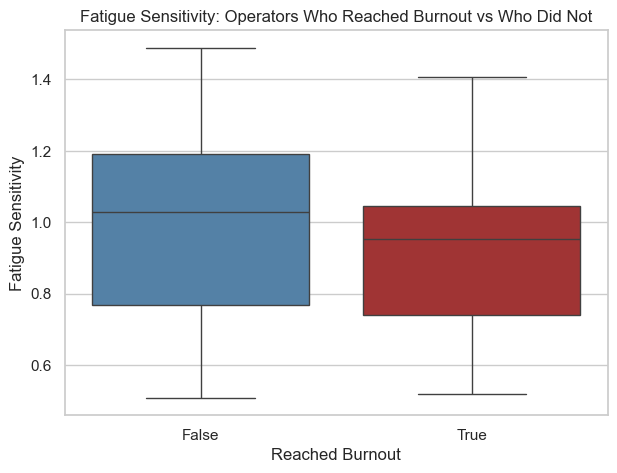

In [9]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=group_comparison, x='reached_burnout', y='fatigue_sensitivity', palette=['steelblue', 'firebrick'])
plt.title("Fatigue Sensitivity: Operators Who Reached Burnout vs Who Did Not")
plt.xlabel("Reached Burnout")
plt.ylabel("Fatigue Sensitivity")
plt.show()

In [10]:
from scipy.stats import ttest_ind

burnout_group = group_comparison[group_comparison['reached_burnout']]['fatigue_sensitivity']
no_burnout_group = group_comparison[~group_comparison['reached_burnout']]['fatigue_sensitivity']

t_stat, p_value = ttest_ind(burnout_group, no_burnout_group, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
print(f"Mean fatigue_sensitivity - reached burnout: {burnout_group.mean():.3f}")
print(f"Mean fatigue_sensitivity - never burnout: {no_burnout_group.mean():.3f}")

T-statistic: -1.354, p-value: 0.1862
Mean fatigue_sensitivity - reached burnout: 0.921
Mean fatigue_sensitivity - never burnout: 1.000


### 5.3 Hypothesis Testing: Does Trait Sensitivity Predict Burnout Onset?

We investigated whether an operator's inherent `fatigue_sensitivity` predicts *if* and *when* they will experience cognitive collapse. 

* **Correlation Analysis:** The relationship between fatigue sensitivity and the exact step of burnout onset yielded a non-significant result ($p = 0.1691$).
* **Independent T-Test:** Comparing the mean sensitivity of operators who collapsed versus those who completed the task safely also showed no statistical difference ($p = 0.1862$).

**Conclusion:** 
Trait sensitivity does not act as a catalyst for burnout. It does not dictate whether an operator will collapse, nor how quickly. Instead, as demonstrated in Chapter 4, its role is strictly conditional: it acts as a severe risk multiplier *only after* the Burnout regime has been triggered by external factors.

In [11]:
# Window size: how many steps before the burnout onset to look at
window = 50

# For each collapsed operator, take the steps in [onset - window, onset], and re-index time relative to onset
segments = []
for _, row in burnout_onset.iterrows():
    traj_id = row['trajectory_id']
    onset = row['burnout_onset_step']

    segment = df[
        (df['trajectory_id'] == traj_id) &
        (df['step'] >= onset - window) &
        (df['step'] <= onset)
    ].copy()

    segment['relative_step'] = segment['step'] - onset  # 0 = burnout onset, negative = steps before
    segments.append(segment)

pre_burnout = pd.concat(segments, ignore_index=True)
pre_burnout.head()

,step,trajectory_id,regime,reaction_time,error_rate,motivation,timestamp,task_type,task_difficulty,time_pressure,error_severity,downstream_cost,risk_score,skill_baseline,fatigue_sensitivity,resilience_factor,mission_failure_probability,expected_loss,intervention_effectiveness,relative_step
0,4555,7,STRESSED,1221.219683,0.146232,0.000000,2023-08-15 19:11:16.321835719,decision,0.660372,high,moderate,2500,64.057617,0.902627,1.037988,1.008311,0.803097,2007.741495,0.910129,-50
1,4556,7,STRESSED,885.030101,0.093807,0.803782,2023-08-15 19:20:08.097026189,monitoring,0.372935,medium,minor,0,44.949474,0.902627,1.037988,1.008311,0.376354,0.000000,0.910129,-49
2,4557,7,STRESSED,597.504567,0.094282,2.451413,2023-08-15 19:27:14.062092643,monitoring,0.615347,medium,minor,0,52.316773,0.902627,1.037988,1.008311,0.557662,0.000000,0.910129,-48
3,4558,7,STRESSED,691.561363,0.094639,1.455823,2023-08-15 19:40:07.589952600,analysis,0.932253,high,minor,50,61.895316,0.902627,1.037988,1.008311,0.766657,38.332864,0.910129,-47
4,4559,7,STRESSED,348.031764,0.094243,1.841209,2023-08-15 19:49:20.853499299,analysis,0.986953,high,minor,50,63.457205,0.902627,1.037988,1.008311,0.793429,39.671455,0.910129,-46


In [12]:
# Map the ordered categories to numbers, so we can average and plot them like a continuous variable
pressure_map = {'low': 0, 'medium': 1, 'high': 2}
pre_burnout['time_pressure_num'] = pre_burnout['time_pressure'].map(pressure_map)

pre_burnout[['time_pressure', 'time_pressure_num']].drop_duplicates()

,time_pressure,time_pressure_num
0,high,2
1,medium,1
816,low,0


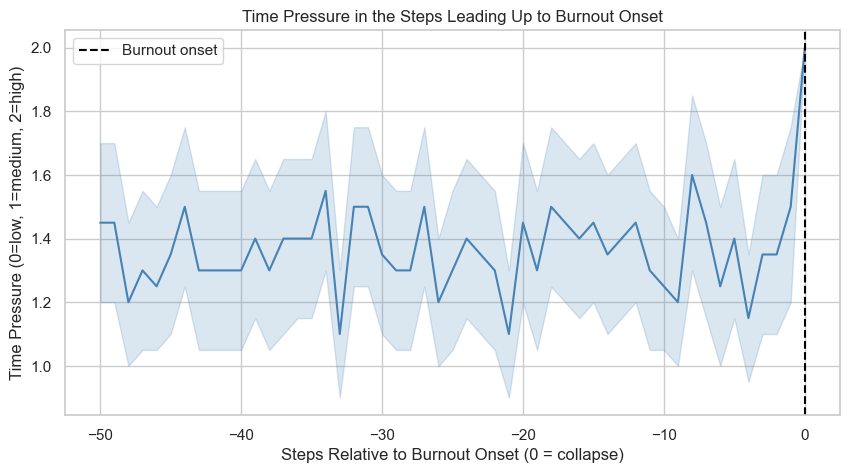

In [13]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=pre_burnout, x='relative_step', y='time_pressure_num', color='steelblue')
plt.axvline(0, color='black', linestyle='--', label='Burnout onset')
plt.title("Time Pressure in the Steps Leading Up to Burnout Onset")
plt.xlabel("Steps Relative to Burnout Onset (0 = collapse)")
plt.ylabel("Time Pressure (0=low, 1=medium, 2=high)")
plt.legend()
plt.show()

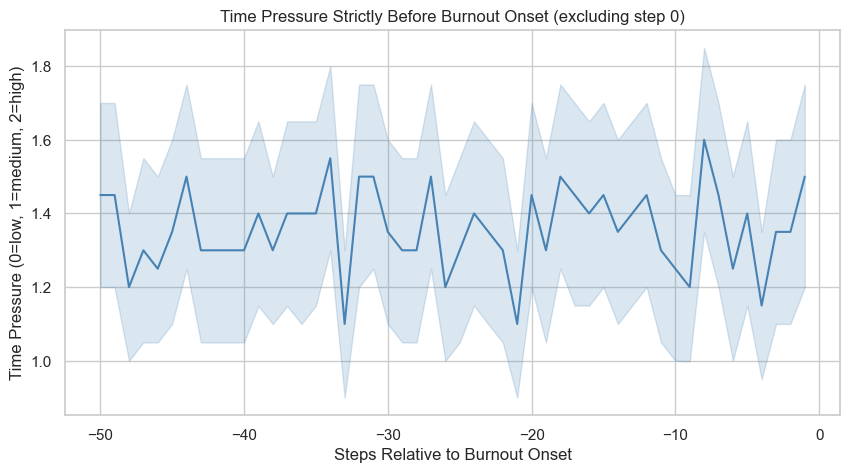

In [14]:
# Zoom on the steps strictly before onset, excluding step 0 itself
pre_onset_only = pre_burnout[pre_burnout['relative_step'] < 0]

plt.figure(figsize=(10, 5))
sns.lineplot(data=pre_onset_only, x='relative_step', y='time_pressure_num', color='steelblue')
plt.title("Time Pressure Strictly Before Burnout Onset (excluding step 0)")
plt.xlabel("Steps Relative to Burnout Onset")
plt.ylabel("Time Pressure (0=low, 1=medium, 2=high)")
plt.show()

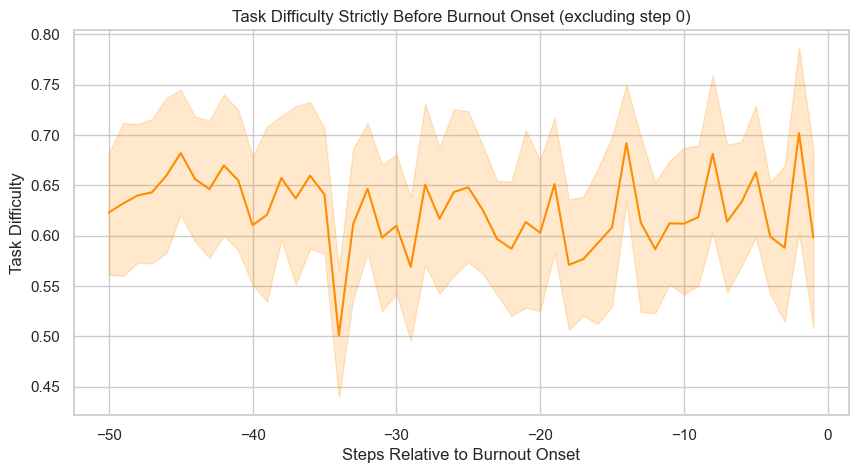

In [15]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=pre_onset_only, x='relative_step', y='task_difficulty', color='darkorange')
plt.title("Task Difficulty Strictly Before Burnout Onset (excluding step 0)")
plt.xlabel("Steps Relative to Burnout Onset")
plt.ylabel("Task Difficulty")
plt.show()

### Findings: No Short-Term Precursors Detected

Neither `time_pressure` nor `task_difficulty` show a systematic trend in the 50 steps preceding burnout onset. Both fluctuate within their usual range throughout the window, with no gradual rise as the collapse approaches.

The apparent spike in `time_pressure` at step 0 disappears entirely once step 0 itself is excluded, suggesting it reflects the burnout state rather than anticipating it — likely a byproduct of how `regime` and `time_pressure` are jointly determined at each step, rather than a genuine early-warning signal.

Combined with the earlier result that `fatigue_sensitivity` does not significantly predict *whether* or *when* an operator collapses, this points to an important negative finding: burnout onset does not appear to be driven by short-term conditions, whether individual or environmental. The trigger, if it exists in the data, is more likely to emerge from accumulation over a much longer horizon — motivating the next step, where we extend the observation window to the full trajectory and examine slower-changing variables such as `motivation` and `resilience_factor`.

## 5.4: Long-Term Precursors: Motivation and Resilience Over the Full Trajectory

Since no short-term precursor was found in the 50 steps before onset, we extend the observation window to the operator's entire trajectory leading up to burnout. Unlike `time_pressure` or `task_difficulty`, which reflect momentary task conditions, `motivation` and `resilience_factor` are more likely to erode gradually, so a slow decline over hundreds or thousands of steps may be invisible in a short window but detectable over the full timeline.

As before, trajectories are aligned by `relative_step` (0 = burnout onset), this time using each operator's full history rather than a fixed 50-step window, allowing operators with earlier or later onset to contribute data over different lengths of relative time.

In [16]:
# Rebuild the segments, this time using the FULL history of each operator up to their onset (no window cutoff)
long_segments = []
for _, row in burnout_onset.iterrows():
    traj_id = row['trajectory_id']
    onset = row['burnout_onset_step']

    segment = df[
        (df['trajectory_id'] == traj_id) &
        (df['step'] <= onset)
    ].copy()

    segment['relative_step'] = segment['step'] - onset
    long_segments.append(segment)

pre_burnout_long = pd.concat(long_segments, ignore_index=True)
print(pre_burnout_long.shape)
print(pre_burnout_long.groupby('trajectory_id')['relative_step'].min())  # how far back each operator's history goes

(86533, 20)
trajectory_id
7     -4605
11    -3576
13    -3078
28    -5842
33    -4374
36    -2066
47    -4684
54    -3953
62    -4608
79    -3512
98    -3348
100   -6019
102   -3522
107   -4331
108   -6008
110   -6817
114   -6818
130   -2049
131   -3494
138   -3809
Name: relative_step, dtype: int64


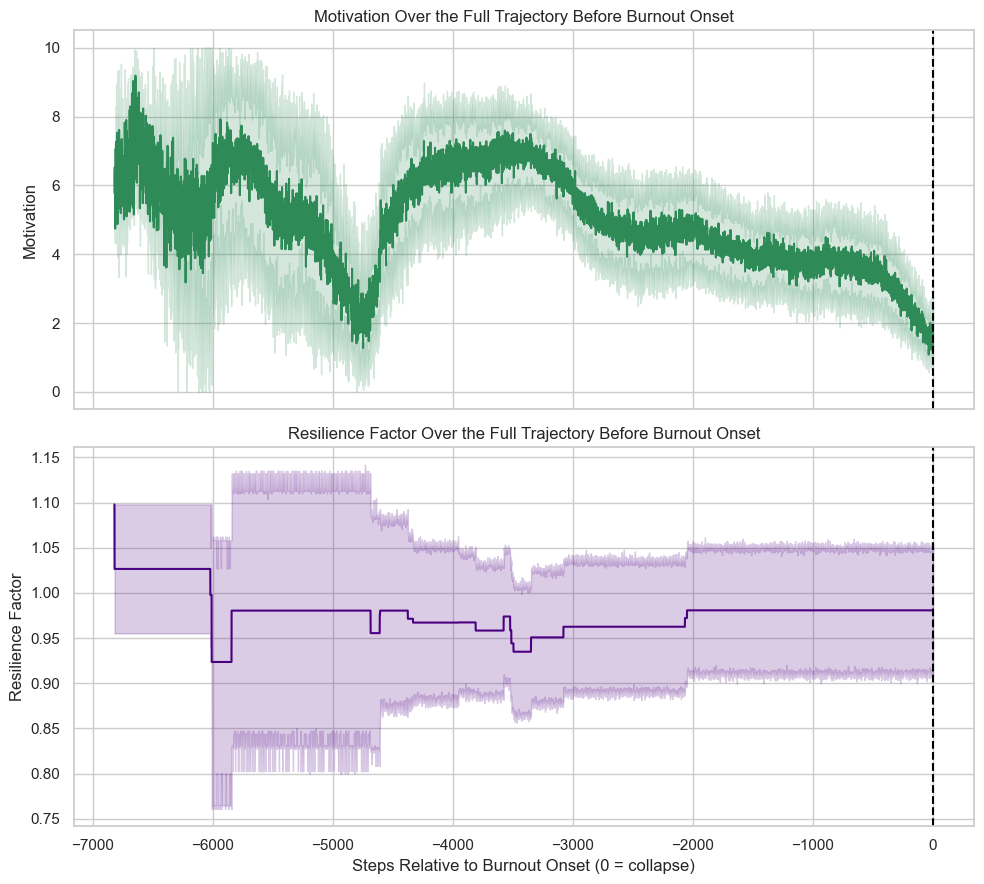

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

sns.lineplot(data=pre_burnout_long, x='relative_step', y='motivation', ax=axes[0], color='seagreen')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title("Motivation Over the Full Trajectory Before Burnout Onset")
axes[0].set_ylabel("Motivation")

sns.lineplot(data=pre_burnout_long, x='relative_step', y='resilience_factor', ax=axes[1], color='indigo')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title("Resilience Factor Over the Full Trajectory Before Burnout Onset")
axes[1].set_xlabel("Steps Relative to Burnout Onset (0 = collapse)")
axes[1].set_ylabel("Resilience Factor")

plt.tight_layout()
plt.show()

In [18]:
# If resilience_factor is constant per operator, each trajectory_id should have only 1 unique value
print(df.groupby('trajectory_id')['resilience_factor'].nunique().describe())

count    140.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: resilience_factor, dtype: float64


In [19]:
# Reuse the same trait-comparison table, adding resilience_factor
traits_resilience = df[['trajectory_id', 'resilience_factor']].drop_duplicates()
burnout_analysis_res = burnout_onset.merge(traits_resilience, on='trajectory_id')

corr_res, p_value_res = pearsonr(burnout_analysis_res['resilience_factor'], burnout_analysis_res['burnout_onset_step'])
print(f"Correlation (resilience vs onset step): {corr_res:.3f}, p-value: {p_value_res:.4f}")

Correlation (resilience vs onset step): -0.164, p-value: 0.4894


In [20]:
# Same True/False grouping already built, just add resilience_factor to it
group_comparison_res = df[['trajectory_id', 'resilience_factor']].drop_duplicates()
group_comparison_res['reached_burnout'] = group_comparison_res['trajectory_id'].isin(burnout_ids)

res_burnout = group_comparison_res[group_comparison_res['reached_burnout']]['resilience_factor']
res_no_burnout = group_comparison_res[~group_comparison_res['reached_burnout']]['resilience_factor']

t_stat_res, p_value_res2 = ttest_ind(res_burnout, res_no_burnout, equal_var=False)
print(f"T-statistic: {t_stat_res:.3f}, p-value: {p_value_res2:.4f}")
print(f"Mean resilience_factor - reached burnout: {res_burnout.mean():.3f}")
print(f"Mean resilience_factor - never burnout: {res_no_burnout.mean():.3f}")

T-statistic: -0.434, p-value: 0.6674
Mean resilience_factor - reached burnout: 0.981
Mean resilience_factor - never burnout: 0.998


### Findings: Traits Don't Predict Burnout, Long-Term Motivation Decline Does

`resilience_factor`, once correctly treated as a fixed trait rather than a time-varying signal, shows no significant relationship with burnout onset — neither with the timing of collapse among operators who do reach BURNOUT (r = -0.164, p = 0.489) nor with the likelihood of reaching it at all (mean 0.981 vs. 0.998, p = 0.667). This mirrors the earlier null result for `fatigue_sensitivity`.

Taken together with the short-term environmental analysis, the picture that emerges is consistent: neither individual traits (`fatigue_sensitivity`, `resilience_factor`) nor immediate task conditions (`time_pressure`, `task_difficulty`) meaningfully predict *whether* or *when* an operator collapses into BURNOUT. The one clear precursor identified in this chapter is the gradual decline in `motivation` over the final ~500-1000 steps before onset — suggesting that burnout, in this dataset, results from a slow depletion process rather than a fixed trait or a short-term environmental trigger.

## Chapter Conclusion: Burnout as Gradual Depletion, Not a Trigger Event

This chapter set out to identify the precise moment at which accumulated fatigue overwhelms the cognitive system, forcing a transition into BURNOUT. The findings across the three analyses converge on an answer that reframes the original question.

**There is no shared "moment" of collapse.** Across the 20 operators who reach BURNOUT, the onset step is scattered widely (from step ~2000 to ~6800), with no dominant timing shared across the sample.

**Neither individual traits nor immediate task conditions explain the collapse.** `fatigue_sensitivity` and `resilience_factor` — both fixed per operator, show no significant relationship with whether an operator collapses or when. Similarly, `time_pressure` and `task_difficulty` remain flat in the 50 steps preceding onset, with no anticipatory rise; the apparent spike in `time_pressure` at step 0 turned out to be concurrent with the burnout state rather than predictive of it.

**The one genuine precursor is motivation, eroding over the long term.** Unlike the short-term variables, `motivation` shows a clear, sustained decline over the final ~500-1000 steps before onset — a slow depletion process rather than a sudden trigger.

Taken together, these results suggest that burnout in this dataset is not a threshold crossed by a fixed vulnerability trait, nor a reaction to a momentary spike in task demands. It behaves more like the endpoint of a gradual erosion of motivation, accumulated over a long horizon, consistent with the interaction found in Chapter 4, where `fatigue_sensitivity` amplified risk only once the system was already destabilized, rather than causing the destabilization itself. This points toward the motivational trajectory, not any single trait or momentary condition, as the process worth modeling further.